In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import jax.tree_util as tree
import jax.typing as jt
import matplotlib.pyplot as plt
import optax
import random
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from netket.jax import jacobian
from itertools import product
from typing import Callable, Sequence
from jax.flatten_util import ravel_pytree
from scipy.optimize import minimize

C:\Users\iclis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin
N = 2
N_ancilla = 2

# Sistema principal: N espines 1/2
# Ancilla: N_ancilla espines 1/2
hi_system = nk.hilbert.Spin(s=1/2, N=N)
# Espacio total = spin ⊗ ancilla
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [4]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    # Estos operadores automáticamente son σ_x^i ⊗ I_R
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [38]:
# Función que emplea el swap trick para calcular la entropía de entrelazamiento
def renyi2_entropy_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Estima la entropía de entrelazamiento de Rényi-2 (S₂) mediante muestreo Monte Carlo
    usando el *swap trick*.

    Calcula:
        S₂ = -log( ⟨SWAP⟩ )

    donde ⟨SWAP⟩ es el valor esperado del operador swap que intercambia el subsistema
    `subsystem_sites` entre dos copias independientes del estado |ψ⟩.

    El valor esperado se estima estocásticamente a partir de muestras generadas con
    `vstate.sample`.

    Args:
        vstate : netket.vqs.MCState
            Estado variacional de NetKet que representa la función de onda |ψ⟩.

        N : int
            Número total de grados de libertad (spins/qubits).
            (Nota: actualmente no se usa explícitamente dentro de la función).

        subsystem_sites : array-like
            Índices de los sitios que definen el subsistema A.
            La entropía se calcula entre A y su complemento.

        n_samples : int
            Número de muestras Monte Carlo usadas para estimar ⟨SWAP⟩.
            Se generan 2 * n_samples configuraciones en total.

        key : int, optional
            Semilla para la permutación aleatoria de las muestras (JAX PRNG key).
            Default: 0.

        debug : bool, optional
            Si True, imprime información detallada sobre:
            - muestras generadas
            - configuraciones intercambiadas
            - valores medios de log |ψ|
            - estimación de ⟨SWAP⟩

    Returns:
       S2 : jax.numpy.DeviceArray
        Estimación Monte Carlo de la entropía de Rényi-2 del subsistema definido
        por `subsystem_sites`.

    """

    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def renyi2_grad_exact(vstate, subsystem_sites, isFullSum=False):
    """
    Calcula el gradiente exacto de la entropía de Rényi-2 usando
    diferenciación automática sobre la función que calcula S₂ exactamente.
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
        grad_S2: gradiente exacto (misma estructura que vstate.parameters)
    """
    
    # Definir una función que solo depende de los parámetros
    def S2_func(params):
        # Crear un estado temporal con los parámetros dados
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hi_extended, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(sampler=vstate.sampler,model=vstate.model,n_samples=vstate.n_samples,)
        vstate_tmp.parameters = params
        S2, _ = renyi2_entropy_exact(vstate_tmp, subsystem_sites)
        return S2
    
    # Usar value_and_grad de JAX para obtener S₂ y su gradiente
    S2, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2, S2_grad

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente, este ultimo utilizando
    el gradiente de la log-amplitud de las samples
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) CREACIÓN DE CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    if debug:
        print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    if debug:
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp((log_s1 + log_s2) - (log_o1 + log_o2))  
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    if debug:
        print(f"⟨SWAP⟩ = {R_mean:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ============================================================
    # 5) GRADIENTES (O_θ = ∂_θ log ψ)
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)  
    
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    # ============================================================
    # 6) ΔO = O(x') + O(y') - O(x) - O(y)
    # ============================================================
    DeltaO = jax.tree_util.tree_map(
        lambda s1, s2, o1, o2: s1 + s2 - o1 - o2,
        O_s1, O_s2, O_o1, O_o2
    )
    
    # ============================================================
    # 7) ⟨R * ΔO⟩ (promedio ponderado por R)
    # ============================================================
    def weighted_average(leaf):
        """
        leaf: array de forma (n_samples, *param_shape)
        Calcula ⟨R * leaf⟩ promediando sobre axis=0
        """
        # Expandir R para broadcasting: (n_samples, 1, 1, ...)
        expanded_R = R.reshape(-1, *([1] * (leaf.ndim - 1)))
        return jnp.mean(expanded_R * leaf, axis=0)
    
    numerator = jax.tree_util.tree_map(weighted_average, DeltaO)
    
    # ============================================================
    # 8) ∂θ S₂ = - ⟨R ΔO⟩ / ⟨R⟩
    # ============================================================
    grad_S2 = jax.tree_util.tree_map(lambda x: -x / R_mean, numerator)
    
    if debug:
        # Calcular norma del gradiente para debug
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_fullsum(vstate, subsystem_sites, debug=False):
    """
    Calcula la entropía de Rényi-2 y su gradiente usando la matriz de densidad reducida.
    Compatible con FullSumState.
    
    Args:
        vstate: estado variacional de NetKet (FullSumState)
        subsystem_sites: índices del subsistema A
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2 = -log(Tr(ρ_A^2))
        grad_S2: gradiente respecto a parámetros
    """
    from netket.jax import jacobian
    
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # =======================================
    # 1) OBTENER VECTOR DE ESTADO COMPLETO 
    # =======================================
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    if debug:
        print(f"Sistema total: {N} qubits")
        print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
        print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # ============================
    # 2) REORGANIZAR COMO MATRIZ 
    # ============================
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Convertir {-1,+1} a {0,1}
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Reorganizar: primero A, luego B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir a índices
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir matriz ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # =====================
    # 3) CALCULAR ρ_A Y S₂ 
    # =====================
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    rho_A_squared = rho_A @ rho_A
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    if debug:
        print(f"|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f}")
        print(f"Tr(ρ_A) = {jnp.trace(rho_A).real:.6f}")
        print(f"Tr(ρ_A²) = {purity:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ========================
    # 4) CALCULAR GRADIENTE
    # ========================
    # Calcular jacobianos O = ∂log(ψ)/∂θ para todas las configuraciones
    O_all = jacobian(vstate._apply_fun, vstate.parameters, basis,
                     model_state=vstate.model_state, mode="real", dense=False)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    # 
    # Tr(ρ_A²) = Σ_{i,j,k} ψ[i,k] ψ*[j,k] ψ[j,ℓ] ψ*[i,ℓ]
    #
    # ∂Tr(ρ_A²)/∂θ = 2 Re[Σ_{i,j,k} (∂ψ[i,k]/∂θ) ψ*[j,k] (ρ_A²)[j,i]]
    
    def compute_grad_for_leaf(O_leaf):
        """Calcula el gradiente para una hoja del árbol de parámetros"""
        param_shape = O_leaf.shape[1:]
        grad_accum = jnp.zeros(param_shape, dtype=jnp.complex128)
        
        n_configs = len(basis)
        
        for config_idx in range(n_configs):
            i_A = idx_A[config_idx]
            i_B = idx_B[config_idx]
            
            # ∂ψ[i_A, i_B]/∂θ = ψ[i_A, i_B] * O[config_idx]
            d_psi_dtheta = psi[config_idx] * O_leaf[config_idx]
            
            # Contribución: Σ_j ψ*[j, i_B] * (ρ_A²)[j, i_A]
            # Equivalente a: (ψ_matrix[:, i_B])† @ (ρ_A²)[:, i_A]
            contribution = jnp.conj(psi_matrix[:, i_B]) @ rho_A_squared[:, i_A]
            
            grad_accum = grad_accum + contribution * O_leaf[config_idx]
        
        return 2.0 * grad_accum.real
    
    grad_trace = jax.tree_util.tree_map(compute_grad_for_leaf, O_all)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    grad_S2 = jax.tree_util.tree_map(
        lambda g: -g / purity,
        grad_trace
    )
    
    if debug:
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente de forma similar a "renyi2_entropy_and_grad_sampled"
    pero numéricamente estable (aún no funciona bien del todo)
    
    Usa logsumexp y diferenciación automática para evitar overflow/underflow.
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO - Dos conjuntos independientes
    # ============================================================
    rng = jax.random.PRNGKey(key)
    rng1, rng2 = jax.random.split(rng)
    
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    
    # Asegurar mismo tamaño
    M = min(samples1.shape[0], samples2.shape[0])
    samples1 = samples1[:M]
    samples2 = samples2[:M]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) PREPARAR SITIOS
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    # Precomputar configuraciones swapeadas (no dependen de params)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], 
                                samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], 
                                samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) FUNCIÓN PARA CALCULAR ln P (PURITY) - VERSIÓN EFICIENTE
    # ============================================================
    def log_psi_fn(params, samples):
        """Helper para evaluar log ψ sin crear vstate temporal"""
        return vstate.model.apply(
            {'params': params}, 
            samples,
            mutable=False
        )
    
    def lnP_estimator(params):
        """
        Calcula ln P_A de forma numéricamente estable usando logsumexp.
        
        P_A = ⟨Q⟩ donde Q_k = |ψ(α',β)|² |ψ(α,β')|² / (|ψ(α,β)|² |ψ(α',β')|²)
        
        ln P_A = logsumexp(log Q_k) - ln M
        """
        # Log-amplitudes evaluadas directamente con el modelo
        log_o1 = log_psi_fn(params, samples1)
        log_o2 = log_psi_fn(params, samples2)
        log_s1 = log_psi_fn(params, swapped1)
        log_s2 = log_psi_fn(params, swapped2)
        
        # log Q_k para cada par de muestras k
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        
        # logsumexp automáticamente maneja la estabilidad numérica
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(M)
        
        # Tomamos la parte real para asegurar que sea un número real
        return lnP.real
    
    # ============================================================
    # 4) CALCULAR S2 Y SU GRADIENTE
    # ============================================================
    # Primero calculamos S2
    lnP = lnP_estimator(vstate.parameters)
    S2 = -lnP  # S2 = -ln(P)
    
    # Gradiente usando diferenciación automática de JAX
    # JAX automáticamente calcula los pesos softmax al diferenciar logsumexp
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters)
    
    # Convertir gradiente de ln P a gradiente de S2
    # ∂S2/∂θ = -∂(ln P)/∂θ
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    # ============================================================
    # 5) DEBUG INFO
    # ============================================================
    if debug:
        # Calcular algunas métricas para verificación
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)
        
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
        
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        print(f"mean log Q: {jnp.mean(log_q_loc):.6f}")
        print(f"std log Q: {jnp.std(log_q_loc):.6f}")
        print(f"ln P = {lnP:.6f}")
        print(f"S₂ = {S2:.6f}")
        
        # Calcular norma del gradiente
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_grad_only_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula SOLO el gradiente de S2.
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    N = vstate.hilbert.size
    
    # Draw two independent replica batches
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    
    # M = min(samples1.shape[0], samples2.shape[0])
    # samples1 = samples1[:M]
    # samples2 = samples2[:M]
    
    def lnP_estimator(params, sigma1, sigma2):
        # Split each replica into A and B
        alpha = sigma1[:, subsystem_sites]
        alpha_p = sigma2[:, subsystem_sites]
        
        all_sites = jnp.arange(N)
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
        beta = sigma1[:, complement_sites]
        beta_p = sigma2[:, complement_sites]
        
        # Swapped configurations
        sigma_a_p_b = jnp.concatenate([alpha_p, beta], axis=-1)
        sigma_a_b_p = jnp.concatenate([alpha, beta_p], axis=-1)
        
        def logpsi_batch(p, σ):
            return vstate.model.apply({"params": p}, σ)
        
        logpsi_ab = logpsi_batch(params, sigma1)
        logpsi_a_p_b_p = logpsi_batch(params, sigma2)
        logpsi_a_p_b = logpsi_batch(params, sigma_a_p_b)
        logpsi_a_b_p = logpsi_batch(params, sigma_a_b_p)
        
        # Factor 2.0 para log|ψ|²
        log_q_loc = 2.0 * (
            (logpsi_a_p_b.real + logpsi_a_b_p.real) - 
            (logpsi_ab.real + logpsi_a_p_b_p.real)
        )
        
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(log_q_loc.shape[0])
        return lnP
    
    # Gradient of ln P (no S2 computed)
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters, samples1, samples2)
    
    # Convert to gradient of S2
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    if debug:
        grad_dense, _ = ravel_pytree(grad_S2)
        grad_norm = jnp.linalg.norm(grad_dense)
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return grad_S2

# Jax para calcular el gradiente de la entropía
def renyi2_value_and_grad(vstate, N, subsystem_sites, n_samples=1000, key=0, debug=False):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada mediante el swap trick
    en función de los parámetros variacionales del estado |ψ⟩,
    '''
    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(vstate.sampler, vstate.model,
                                  n_samples=vstate.n_samples)
        vstate_tmp.parameters = params
        S2 = renyi2_entropy_sampled(vstate_tmp, subsystem_sites, n_samples, key, debug)
        return S2

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    if debug:
        grad_norm = jnp.linalg.norm(nk.jax.jax.flatten_util.ravel_pytree(S2_grad)[0])
        print(f"S₂={S2_val}, ∇S₂={grad_norm}")

    return S2_val, S2_grad

def renyi2_value_and_grad2(vstate, hilbert, partition, isFullSum=False):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada la implementación de NetKet
    en función de los parámetros variacionales del estado |ψ⟩,
    '''

    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(
        hilbert, partition=partition
    )

    def S2_func(params):
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hi_extended, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(sampler=vstate.sampler,model=vstate.model,n_samples=vstate.n_samples,)
        vstate_tmp.parameters = params
        return vstate_tmp.expect(S2_obs).mean.real

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2_val, S2_grad


In [6]:
def renyi2_entropy_lambda_integral(vstate,subsystem_sites,n_samples,n_lambda=10,key=0,debug=False,):
    """
    Calcula S₂ usando el método de la λ-integral.
    Solo la entropía, sin el gradiente.

    S₂ = - ∫₀¹ dλ ⟨ ln R ⟩_{P_λ}
    """

    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    key_obj = jax.random.PRNGKey(key)

    lambda_grid = jnp.linspace(0.0, 1.0, n_lambda)
    f_vals = []

    for lam in lambda_grid:
        key_obj, subkey = jax.random.split(key_obj)

        # =====================================================
        # 1) MUESTREO
        # =====================================================
        all_samples = (
            vstate.sample(
                n_samples=2 * n_samples,
                n_discard_per_chain=500,
            )
            .reshape(-1, vstate.hilbert.size)
        )

        all_samples = jax.random.permutation(subkey, all_samples, axis=0)

        samples1 = all_samples[:n_samples].astype(jnp.float32)
        samples2 = all_samples[n_samples:2*n_samples].astype(jnp.float32)

        # =====================================================
        # 2) SWAP CONFIGS
        # =====================================================
        all_sites = jnp.arange(samples1.shape[1])
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)

        swapped1 = jnp.concatenate(
            [samples2[:, subsystem_sites], samples1[:, complement_sites]], 
            axis=1
        )
        swapped2 = jnp.concatenate(
            [samples1[:, subsystem_sites], samples2[:, complement_sites]], 
            axis=1
        )

        # =====================================================
        # 3) LOG-AMPLITUDES
        # =====================================================
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)

        log_R = (log_s1 + log_s2) - (log_o1 + log_o2)

        # =====================================================
        # 4) PESOS P_λ
        # =====================================================
        log_weights = lam * log_R
        log_weights -= jax.nn.logsumexp(log_weights)
        weights = jnp.exp(log_weights)

        # =====================================================
        # 5) f(λ) = ⟨ln R⟩_λ
        # =====================================================
        f_lam = jnp.sum(weights * log_R)
        f_vals.append(f_lam)

        if debug:
            print(f"λ = {float(lam):.3f}  f(λ) = {float(f_lam):.6f}")

    # =====================================================
    # 6) INTEGRACIÓN (trapecio)
    # =====================================================
    f_vals = jnp.array(f_vals)
    dlam = lambda_grid[1] - lambda_grid[0]

    S2 = -(
        dlam
        * (
            0.5 * f_vals[0]
            + jnp.sum(f_vals[1:-1])
            + 0.5 * f_vals[-1]
        )
    )

    if debug:
        print("\nRESULTADO FINAL")
        print(f"S₂ = {float(S2):.6f}")

    return S2

def renyi2_value_and_grad_lambda(vstate,hilbert,subsystem_sites,n_samples,n_lambda=10,key=0,isFullSum=False,debug=False,):
    """
    Calcula S₂ y su gradiente usando el método de la λ-integral
    Con diferenciación automática de JAX.

    Args:
        vstate: estado variacional
        hilbert: espacio de Hilbert completo (sistema + ancilla)
        subsystem_sites: índices del subsistema
        n_samples: muestras por cada λ
        n_lambda: puntos en la integral
        key: semilla aleatoria
        isFullSum: si True, usa FullSumState (solo para test pequeños)
        debug: modo depuración

    Returns:
        S2_val: entropía de Rényi-2
        S2_grad: gradiente respecto a parámetros
    """

    # =====================================================
    # 1) DEFINIR FUNCIÓN QUE CALCULA S₂ DADOS LOS PARÁMETROS
    # =====================================================
    def S2_func(params):
        # Crear estado temporal con los parámetros dados
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hilbert, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(
                sampler=vstate.sampler,
                model=vstate.model,
                n_samples=vstate.n_samples,
            )
        vstate_tmp.parameters = params

        # Calcular S₂ con tu función de integral sobre λ
        S2 = renyi2_entropy_lambda_integral(
            vstate_tmp,
            subsystem_sites,
            n_samples=n_samples,
            n_lambda=n_lambda,
            key=key,
            debug=debug,
        )
        return S2

    # =====================================================
    # 2) USAR value_and_grad DE JAX
    # =====================================================
    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)

    if debug:
        print(f"\n📊 RESULTADO FINAL (λ-integral + AD):")
        print(f"S₂ = {S2_val:.6f}")
        grad_norm = jnp.linalg.norm(
            jax.flatten_util.ravel_pytree(S2_grad)[0]
        )
        print(f"‖∇S₂‖ = {grad_norm:.6f}")

    return S2_val, S2_grad

In [7]:
def renyi2_entropy_and_grad_lambda_integral(vstate,subsystem_sites,n_samples,n_lambda=10,key=0,debug=False,):
    """
    Calcula S₂ y ∇S₂ usando el método de la λ-integral
    basado en Drut & Porter (2016).

    S₂ = - ∫₀¹ dλ ⟨ ln R ⟩_{P_λ}
    ∇S₂ = - ∫₀¹ [ ⟨∇lnR⟩_{P_λ} + λ Cov_{P_λ}(lnR, ∇lnR) ] dλ
    """

    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    key_obj = jax.random.PRNGKey(key)

    lambda_grid = jnp.linspace(0.0, 1.0, n_lambda)

    f_vals = []
    grad_f_vals = []

    for lam in lambda_grid:

        key_obj, subkey = jax.random.split(key_obj)

        # =====================================================
        # 1) MUESTREO
        # =====================================================
        all_samples = (
            vstate.sample(
                n_samples=2 * n_samples,
                n_discard_per_chain=500,
            )
            .reshape(-1, vstate.hilbert.size)
        )

        all_samples = jax.random.permutation(subkey, all_samples, axis=0)

        samples1 = all_samples[:n_samples].astype(jnp.float32)
        samples2 = all_samples[n_samples:2*n_samples].astype(jnp.float32)

        # =====================================================
        # 2) SWAP CONFIGS (concatenación)
        # =====================================================
        all_sites = jnp.arange(samples1.shape[1])
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)

        swapped1 = jnp.concatenate(
            [samples2[:, subsystem_sites], samples1[:, complement_sites]], 
            axis=1
        )
        swapped2 = jnp.concatenate(
            [samples1[:, subsystem_sites], samples2[:, complement_sites]], 
            axis=1
        )

        # =====================================================
        # 3) LOG-AMPLITUDES
        # =====================================================
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)

        log_R = (log_s1 + log_s2) - (log_o1 + log_o2)
        R = jnp.exp(log_R)

        # =====================================================
        # 4) GRADIENTES ∇ ln R
        # =====================================================
        O_o1 = jacobian(
            vstate._apply_fun,
            vstate.parameters,
            samples1,
            model_state=vstate.model_state,
            mode="real",
            dense=False,
        )

        O_o2 = jacobian(
            vstate._apply_fun,
            vstate.parameters,
            samples2,
            model_state=vstate.model_state,
            mode="real",
            dense=False,
        )

        O_s1 = jacobian(
            vstate._apply_fun,
            vstate.parameters,
            swapped1,
            model_state=vstate.model_state,
            mode="real",
            dense=False,
        )

        O_s2 = jacobian(
            vstate._apply_fun,
            vstate.parameters,
            swapped2,
            model_state=vstate.model_state,
            mode="real",
            dense=False,
        )

        grad_lnR = jax.tree_util.tree_map(
            lambda s1, s2, o1, o2: s1 + s2 - o1 - o2,
            O_s1,
            O_s2,
            O_o1,
            O_o2,
        )

        # =====================================================
        # 5) PESOS P_λ
        # =====================================================
        log_weights = lam * log_R
        log_weights -= jax.nn.logsumexp(log_weights)
        weights = jnp.exp(log_weights)

        # =====================================================
        # 6) f(λ) = ⟨ln R⟩_λ
        # =====================================================
        f_lam = jnp.sum(weights * log_R)
        f_vals.append(f_lam)

        # =====================================================
        # 7) ⟨∇ln R⟩_λ
        # =====================================================
        def weighted_mean(leaf):
            w = weights.reshape(-1, *([1] * (leaf.ndim - 1)))
            return jnp.sum(w * leaf, axis=0)

        mean_grad = jax.tree_util.tree_map(weighted_mean, grad_lnR)

        # =====================================================
        # 8) Covarianza: ⟨lnR ∇lnR⟩_λ - ⟨lnR⟩_λ ⟨∇lnR⟩_λ
        # =====================================================
        def weighted_lnR_grad(leaf):
            w = weights.reshape(-1, *([1] * (leaf.ndim - 1)))
            lnR_exp = log_R.reshape(-1, *([1] * (leaf.ndim - 1)))
            return jnp.sum(w * lnR_exp * leaf, axis=0)

        mean_lnR_grad = jax.tree_util.tree_map(weighted_lnR_grad, grad_lnR)

        cov = jax.tree_util.tree_map(
            lambda a, b: a - f_lam * b,
            mean_lnR_grad,
            mean_grad,
        )

        # =====================================================
        # 9) ∇f(λ) = ⟨∇lnR⟩_λ + λ * Cov 
        # =====================================================
        grad_f = jax.tree_util.tree_map(
            lambda mg, c: mg + lam * c,
            mean_grad,
            cov,
        )

        grad_f_vals.append(grad_f)


        # ============================
        # DEBUG ESTADÍSTICO 
        # ============================
        if debug:

            # ---- Effective Sample Size ----
            ess = 1.0 / jnp.sum(weights**2)
            ess_frac = ess / n_samples

            # ---- Varianza de logR ----
            mean_logR = f_lam
            var_logR = jnp.sum(weights * (log_R - mean_logR) ** 2)

            # ---- Norma de grad_lnR por sample ----
            flat_grad_samples = []
            for leaf in jax.tree_util.tree_leaves(grad_lnR):
                flat_grad_samples.append(
                    leaf.reshape(n_samples, -1)
                )
            flat_grad_samples = jnp.concatenate(flat_grad_samples, axis=1)

            grad_norm_samples = jnp.linalg.norm(flat_grad_samples, axis=1)

            mean_grad_norm = jnp.sum(weights * grad_norm_samples)
            var_grad_norm = jnp.sum(
                weights * (grad_norm_samples - mean_grad_norm) ** 2
            )

            # ---- Norma de la covarianza ----
            flat_cov, _ = ravel_pytree(cov)
            cov_norm = jnp.linalg.norm(flat_cov)

            # ---- Información de pesos ----
            w_min = jnp.min(weights)
            w_max = jnp.max(weights)

            weight_entropy = -jnp.sum(weights * jnp.log(weights + 1e-12))

            print(f"\nλ = {float(lam):.3f}")
            print(f"  f(λ) = {float(f_lam):.6f}")
            print(f"  ESS = {float(ess):.1f}  ({float(ess_frac*100):.2f}% of samples)")
            print(f"  Var(logR)_λ = {float(var_logR):.6f}")
            print(f"  Var(||∇lnR||)_λ = {float(var_grad_norm):.6f}")
            print(f"  ||Cov|| = {float(cov_norm):.6f}")
            print(f"  w_min = {float(w_min):.2e}")
            print(f"  w_max = {float(w_max):.2e}")
            print(f"  Weight entropy = {float(weight_entropy):.6f}")


    # =====================================================
    # 10) INTEGRACIÓN (trapecio)
    # =====================================================
    f_vals = jnp.array(f_vals)
    dlam = lambda_grid[1] - lambda_grid[0]

    S2 = -(
        dlam
        * (
            0.5 * f_vals[0]
            + jnp.sum(f_vals[1:-1])
            + 0.5 * f_vals[-1]
        )
    )

    # Aplanar gradientes para integrar
    flat_grads = []
    unravel = None
    for g in grad_f_vals:
        flat, un = ravel_pytree(g)
        if unravel is None:
            unravel = un
        flat_grads.append(flat)

    flat_grads = jnp.stack(flat_grads)

    grad_S2_flat = -(
        dlam
        * (
            0.5 * flat_grads[0]
            + jnp.sum(flat_grads[1:-1], axis=0)
            + 0.5 * flat_grads[-1]
        )
    )

    grad_S2 = unravel(grad_S2_flat)

    if debug:
        print("\nRESULTADO FINAL")
        print("S₂ =", float(S2))
        print("||∇S₂|| =", float(jnp.linalg.norm(grad_S2_flat)))

    return S2, grad_S2

In [8]:
class GaugeFixedARNN(nn.Module):
    """
    Versión diferenciable usando codificación suave.
    Cada g(s_i,a_i) se parametriza con una matriz 2*2 pero sin índices enteros.
    """
    N: int
    alpha: int = 1

    def setup(self):
        # RBMs independientes para sistema y ancilla
        self.rbm_sys = nk.models.ARNNDense(
            hilbert=hi_system,
            layers=1,
            features=16,
            param_dtype=jnp.float64
        )
        # self.rbm_anc = nk.models.RBM(alpha=self.alpha, param_dtype=jnp.float64)

        # Matriz 2x2 por sitio: J[i, s_val, a_val]
        self.J = self.param(
            "J",
            nn.initializers.normal(0.01),
            (self.N, 2, 2)
        )

    def __call__(self, sigma):
        s = sigma[..., :self.N]  # shape (batch, N)
        a = sigma[..., self.N:]  # shape (batch, N)

        # Forward RBMs
        log_psi_s = self.rbm_sys(s)
        log_psi_a = self.rbm_sys(a)

        # # Codificación suave de spins: -1 -> [1,0], +1 -> [0,1]
        # s0 = 0.5 * (1 - s)
        # s1 = 0.5 * (1 + s)
        # a0 = 0.5 * (1 - a)
        # a1 = 0.5 * (1 + a)

        # # coupling diferenciable
        # # broadcasting: J shape (N,2,2), s0,s1,a0,a1 shape (batch,N)
        # coupling = (
        #     self.J[:,0,0] * s0 * a0 +
        #     self.J[:,0,1] * s0 * a1 +
        #     self.J[:,1,0] * s1 * a0 +
        #     self.J[:,1,1] * s1 * a1
        # )
        # coupling = jnp.sum(coupling, axis=-1)  # suma sobre sitios

        log_psi = log_psi_s + log_psi_a #+ coupling

        # Estabilización opcional
        log_psi = jnp.clip(log_psi, -20.0, 20.0)
        return log_psi

In [9]:
class GaugeFixedRBM(nn.Module):
    """
    Versión diferenciable usando codificación suave.
    Cada g(s_i,a_i) se parametriza con una matriz 2*2 pero sin índices enteros.
    """
    N: int
    alpha: int = 1

    def setup(self):
        # RBMs  para sistema y ancilla
        self.rbm_sys_anc = nk.models.RBM(alpha=self.alpha, param_dtype=jnp.float64)

        # Matriz 2x2 por sitio: J[i, s_val, a_val]
        self.J = self.param(
            "J",
            nn.initializers.normal(0.01),
            (self.N, 2, 2)
        )

    def __call__(self, sigma):
        s = sigma[..., :self.N]  # shape (batch, N)
        a = sigma[..., self.N:]  # shape (batch, N)

        # Forward RBMs
        log_psi_s = self.rbm_sys_anc(s)
        log_psi_a = self.rbm_sys_anc(a)

        # Codificación suave de spins: -1 -> [1,0], +1 -> [0,1]
        s0 = 0.5 * (1 - s)
        s1 = 0.5 * (1 + s)
        a0 = 0.5 * (1 - a)
        a1 = 0.5 * (1 + a)

        # coupling diferenciable
        # broadcasting: J shape (N,2,2), s0,s1,a0,a1 shape (batch,N)
        coupling = (
            self.J[:,0,0] * s0 * a0 +
            self.J[:,0,1] * s0 * a1 +
            self.J[:,1,0] * s1 * a0 +
            self.J[:,1,1] * s1 * a1
        )
        coupling = jnp.sum(coupling, axis=-1)  # suma sobre sitios

        log_psi = log_psi_s + log_psi_a + coupling

        # Estabilización opcional
        log_psi = jnp.clip(log_psi, -20.0, 20.0)
        return log_psi

In [10]:
class SchmidtRBM(nn.Module):
    """
    Ansatz tipo Schmidt:
    - RBM compartida para sistema y ancilla
    - Transformación aprendible en la ancilla (rotación variacional)
    """
    N: int
    alpha: int = 1

    def setup(self):
        # RBM compartida
        self.rbm = nk.models.RBM(
            alpha=self.alpha,
            param_dtype=jnp.float64
        )

        # Rotación global de la ancilla
        self.U = self.param(
            "U",
            nn.initializers.orthogonal(),
            (self.N, self.N)
        )

    def __call__(self, sigma):
        s = sigma[..., :self.N]   # sistema
        a = sigma[..., self.N:]   # ancilla

        # Rotación aprendida de la ancilla
        a_rot = jnp.tanh(a @ self.U)

        log_psi_s = self.rbm(s)
        log_psi_a = self.rbm(a_rot)

        log_psi = log_psi_s + log_psi_a
        return jnp.clip(log_psi, -20.0, 20.0)


In [11]:
#MultiLayerPerceptron, model con simetría Z2, 
REAL_DTYPE = jnp.asarray(1.0).dtype
class MultiLayerPerceptron(nn.Module):
    """Flax module for a Multi-layer perceptron architecture with normalization.

    Args:
        layer_widths: Sequence of integers that define both the number of layers
            and their widths.
        activation_funcion: The activation function that will be applied after
            each dense layer.
        kernel_init: Function to initialize the trainable parameters.

    Returns:
        A jax array with the output of the net.
    """

    layer_widths: Sequence[int]
    activation_function: Callable = nn.swish
    kernel_init: Callable = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, x) -> jt.ArrayLike:
        for w in self.layer_widths:
            # We cannot use LayerNorm when the output has size 1, since
            # that would destroy the data.
            if w == 1:
                normalizer = lambda x: x
            else:
                normalizer = nn.LayerNorm(param_dtype=REAL_DTYPE)
            x = self.activation_function(
                normalizer(
                    nn.Dense(
                        w,
                        kernel_init=self.kernel_init,
                        param_dtype=REAL_DTYPE,
                    )(x)
                )
            )
        return x.squeeze(axis=-1)
    
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        # worker = nk.models.RBM(alpha=self.alpha, param_dtype=float) 
        # worker = MultiLayerPerceptron(layer_widths=[8,16,8,1])
        # worker = nk.models.ARNNDense(
        #     hilbert= nk.hilbert.Spin(s=1/2, N=N+N_ancilla),
        #     layers=1,           
        #     features=16,        
        #     activation=jax.nn.gelu,
        #     kernel_init=nn.initializers.variance_scaling(
        #         scale=0.05,  
        #         mode='fan_in',
        #         distribution='truncated_normal'
        #     ),
        #     bias_init=nn.initializers.constant(0.1)
        # )
        worker = GaugeFixedRBM(N, self.alpha)
        # worker = GaugeFixedARNN(N)
        # worker = SchmidtRBM(N, self.alpha)

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res
        # return nk.nn.log_cosh(res)

Step 0: S₂(SWAP)=0.001063, S₂(NK)=0.000755, S₂(ρₛ)=0.000502, |∇S₂| = 0.04240018
Step 20: S₂(SWAP)=0.019300, S₂(NK)=0.024393, S₂(ρₛ)=0.022644, |∇S₂| = 0.04817839
Step 40: S₂(SWAP)=0.346919, S₂(NK)=0.350598, S₂(ρₛ)=0.321879, |∇S₂| = 0.07564272
Step 60: S₂(SWAP)=0.698569, S₂(NK)=0.638331, S₂(ρₛ)=0.733320, |∇S₂| = 0.08761991
Step 80: S₂(SWAP)=0.747967, S₂(NK)=1.433120, S₂(ρₛ)=0.761544, |∇S₂| = 0.01188992
Step 100: S₂(SWAP)=0.753248, S₂(NK)=1.428540, S₂(ρₛ)=0.737353, |∇S₂| = 0.00469362
Step 120: S₂(SWAP)=0.699798, S₂(NK)=1.006892, S₂(ρₛ)=0.724824, |∇S₂| = 0.01362910
Step 140: S₂(SWAP)=0.757610, S₂(NK)=0.554733, S₂(ρₛ)=0.754977, |∇S₂| = 0.00987474
Step 160: S₂(SWAP)=0.622094, S₂(NK)=0.487685, S₂(ρₛ)=0.723876, |∇S₂| = 0.06590585
Step 180: S₂(SWAP)=1.031266, S₂(NK)=1.172866, S₂(ρₛ)=1.204949, |∇S₂| = 0.00762628
Step 200: S₂(SWAP)=0.805718, S₂(NK)=0.852056, S₂(ρₛ)=0.885248, |∇S₂| = 0.02241697
Step 220: S₂(SWAP)=0.968338, S₂(NK)=1.167422, S₂(ρₛ)=1.092450, |∇S₂| = 0.05527927
Step 240: S₂(SWAP)=1.3

<function matplotlib.pyplot.show(close=None, block=None)>

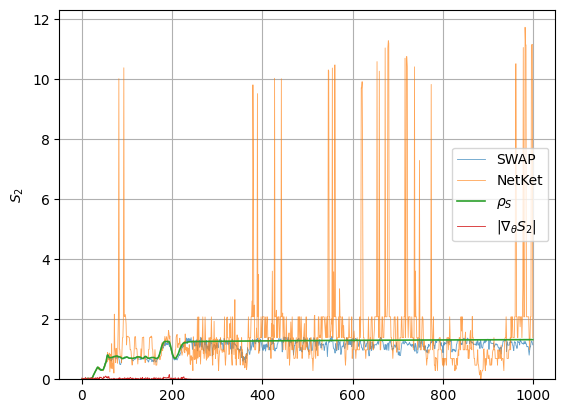

In [46]:
#Comprobar que la derivada del gradiente funciona
#Se busca el estado que maximiza S₂, en nuestro caso max(S₂)=ln(N+N_ancilla)

partition = list(range(N))  
# sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# model = GaugeFixedRBM(N)
vstate = nk.vqs.MCState(sampler, model, n_samples=3008)
vstate.init_parameters
lr = 0.8
optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.sgd(learning_rate=lr,momentum=0.9))

opt_state = optimizer.init(vstate.parameters)

S2_history_swap = []
S2_history_nk = []
S2_history_trace = []
S2_grad_history= []
s2_lambda_history = []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    S2_nk = vstate.expect(S2_obs).mean.real*np.log(2)
    S2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, vstate.n_samples)
    # S2, S2_grad_2 = renyi2_grad_exact(vstate, partition)
    # S2_lambda, _ = renyi2_value_and_grad_lambda(vstate, hi_extended, partition, vstate.n_samples, 10)
    # S2_lambda, S2_grad_2 = renyi2_entropy_and_grad_lambda_integral(vstate, partition, vstate.n_samples, n_lambda=20)
    S2_trace = renyi2_entropy_exact(vstate, partition)[0]
    S2_grad = jnp.linalg.norm(jax.flatten_util.ravel_pytree(S2_grad_2)[0])
    
    S_grad = jax.tree_util.tree_map(
        lambda grad_S2:  - grad_S2,
        S2_grad_2
    )
    
    updates, opt_state = optimizer.update(S_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)

    S2_history_swap.append(S2)
    S2_history_nk.append(S2_nk)
    S2_history_trace.append(S2_trace)
    # s2_lambda_history.append(S2_lambda)
    S2_grad_history.append(S2_grad)
    a = vstate.expect_and_grad(H_extended)
    
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(S_grad)[0])
        print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, S₂(ρₛ)={S2_trace:.6f}, |∇S₂| = {S2_grad:.8f}")

plt.plot(S2_history_swap, label="SWAP", linewidth=0.6, alpha=0.7)
plt.plot(S2_history_nk, label="NetKet", linewidth=0.6, alpha=0.7)
plt.plot(S2_history_trace, label=r"$\rho_S$", linewidth=1.2)
# plt.plot(s2_lambda_history, label=r"$\lambda$", linewidth=0.6, alpha=0.9)
plt.plot(S2_grad_history, label=r"$|\nabla_\theta S_2$|", linewidth=0.6,)
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

In [13]:
def visualize_s2_landscape(vstate, partition, optimal_params, n_samples=10000):
    """
    Visualiza el landscape de S₂ alrededor de los parámetros óptimos.
    
    Args:
        vstate: Estado variacional
        partition: Partición para calcular entrelazamiento
        optimal_params: Parámetros óptimos encontrados
        n_samples: Número de muestras para calcular S₂
    """
    
    # Aplanar parámetros completamente (incluyendo arrays internos)
    flat_params, tree_def = jax.tree_util.tree_flatten(optimal_params)
    
    # Aplanar completamente todos los arrays a escalares individuales
    all_scalars = []
    param_shapes = []
    param_indices = []  # (array_idx, element_idx)
    
    for i, param in enumerate(flat_params):
        if isinstance(param, (jnp.ndarray, np.ndarray)):
            param_flat = param.flatten()
            for j, scalar in enumerate(param_flat):
                all_scalars.append(float(scalar))
                param_shapes.append(param.shape)
                param_indices.append((i, j))
        else:
            all_scalars.append(float(param))
            param_shapes.append(())
            param_indices.append((i, -1))
    
    n_params = len(all_scalars)
    print(f"Número total de parámetros escalares: {n_params}")
    
    # Seleccionar dos parámetros escalares para explorar
    param_idx_1 = 0
    param_idx_2 = min(1, n_params - 1)
    
    # Definir rangos de exploración 
    param_1_opt = all_scalars[param_idx_1]
    param_2_opt = all_scalars[param_idx_2]
    
    range_factor = 10
    range_abs = max(abs(param_1_opt), 0.1)  # Evitar rangos de cero
    param_1_range = np.linspace(
        param_1_opt - range_factor * range_abs,
        param_1_opt + range_factor * range_abs,
        100
    )
    range_abs = max(abs(param_2_opt), 0.1)
    param_2_range = np.linspace(
        param_2_opt - range_factor * range_abs,
        param_2_opt + range_factor * range_abs,
        100
    )
    
    # ========== CORTE 2D ==========
    print("Generando landscape 2D...")
    S2_landscape = np.zeros((len(param_1_range), len(param_2_range)))
    
    for i, p1 in enumerate(param_1_range):
        for j, p2 in enumerate(param_2_range):
            # Crear nueva configuración de parámetros
            new_scalars = all_scalars.copy()
            new_scalars[param_idx_1] = p1
            new_scalars[param_idx_2] = p2
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # Calcular S₂
            # S2 = renyi2_entropy_sampled(vstate, N, partition, n_samples)
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_landscape[i, j] = S2
        
        if i % 5 == 0:
            print(f"  Progreso: {i}/{len(param_1_range)}")
    
    # Visualizar corte 2D
    fig = plt.figure(figsize=(12, 5))
    
    # Subplot 1: Mapa de calor
    ax1 = fig.add_subplot(121)
    im = ax1.contourf(param_2_range, param_1_range, S2_landscape, 
                      levels=20, cmap='viridis')
    ax1.plot(param_2_opt, param_1_opt, 'r*', markersize=15, 
             label='Óptimo encontrado')
    ax1.set_xlabel(f'Parámetro {param_idx_2}')
    ax1.set_ylabel(f'Parámetro {param_idx_1}')
    ax1.set_title('Landscape de S₂ (Corte 2D)')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='S₂')
    
    # Subplot 2: Superficie 3D
    ax2 = fig.add_subplot(122, projection='3d')
    P1, P2 = np.meshgrid(param_2_range, param_1_range)
    surf = ax2.plot_surface(P2, P1, S2_landscape, cmap='viridis', 
                            alpha=0.8, edgecolor='none')
    ax2.scatter([param_2_opt], [param_1_opt], [S2_landscape[len(param_1_range)//2, len(param_2_range)//2]], 
                color='red', s=100, label='Óptimo')
    ax2.set_xlabel(f'Parámetro {param_idx_2}')
    ax2.set_ylabel(f'Parámetro {param_idx_1}')
    ax2.set_zlabel('S₂')
    ax2.set_title('Superficie de S₂')
    plt.colorbar(surf, ax=ax2, shrink=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # ========== CORTES 1D ==========
    print("\nGenerando cortes 1D...")
    
    # Seleccionar algunos parámetros importantes para visualizar
    params_to_plot = min(4, n_params)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx in range(params_to_plot):
        param_opt = all_scalars[idx]
        range_abs = max(abs(param_opt), 0.1)
        param_range = np.linspace(
            param_opt - range_factor * range_abs,
            param_opt + range_factor * range_abs,
            50
        )
        
        S2_values = []
        for p in param_range:
            new_scalars = all_scalars.copy()
            new_scalars[idx] = p
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # S2, _ = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=idx*1000+len(S2_values))
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_values.append(S2)
        
        axes[idx].plot(param_range, S2_values, 'b-', linewidth=2)
        axes[idx].axvline(param_opt, color='r', linestyle='--', 
                         label='Óptimo encontrado')
        axes[idx].set_xlabel(f'Parámetro {idx}')
        axes[idx].set_ylabel('S₂')
        axes[idx].set_title(f'Corte 1D: Parámetro {idx}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
        
        print(f"  Completado parámetro {idx}/{params_to_plot}")
    
    plt.tight_layout()
    plt.show()
    
    # Restaurar parámetros óptimos
    vstate.parameters = optimal_params

def visualize_free_energy_landscape(vstate, Hamiltonian, partition, optimal_params, T, exactS2=True):
    """
    Visualiza el landscape de F = <H> - T S₂ alrededor de los parámetros óptimos,
    con cortes 2D y 4 cortes 1D respecto a parámetros aleatorios.

    Args:
        vstate: Estado variacional
        Hamiltonian: Hamiltoniano del sistema
        partition: Partición para calcular entrelazamiento
        optimal_params: Parámetros óptimos encontrados
        T: Temperatura para F
        n_samples: Número de muestras para calcular S₂
    """

    # Aplanar parámetros completamente (incluyendo arrays internos)
    flat_params, tree_def = jax.tree_util.tree_flatten(optimal_params)
    all_scalars = []
    param_shapes = []
    param_indices = []  # (array_idx, element_idx)

    for i, param in enumerate(flat_params):
        if isinstance(param, (jnp.ndarray, np.ndarray)):
            param_flat = param.flatten()
            for j, scalar in enumerate(param_flat):
                all_scalars.append(float(scalar))
                param_shapes.append(param.shape)
                param_indices.append((i, j))
        else:
            all_scalars.append(float(param))
            param_shapes.append(())
            param_indices.append((i, -1))

    n_params = len(all_scalars)
    print(f"Número total de parámetros escalares: {n_params}")

    # Seleccionar dos parámetros escalares para explorar 2D
    param_idx_1 = 0
    param_idx_2 = min(1, n_params - 1)
    param_1_opt = all_scalars[param_idx_1]
    param_2_opt = all_scalars[param_idx_2]

    range_factor = 10
    range_abs = max(abs(param_1_opt), 0.1)
    param_1_range = np.linspace(param_1_opt - range_factor * range_abs,
                                param_1_opt + range_factor * range_abs, 100)
    range_abs = max(abs(param_2_opt), 0.1)
    param_2_range = np.linspace(param_2_opt - range_factor * range_abs,
                                param_2_opt + range_factor * range_abs, 100)

    # ========== CORTE 2D ==========
    F_landscape = np.zeros((len(param_1_range), len(param_2_range)))

    for i, p1 in enumerate(tqdm(param_1_range, desc="Calculando F_landscape")):
        for j, p2 in enumerate(param_2_range):
            # Crear nueva configuración de parámetros
            new_scalars = all_scalars.copy()
            new_scalars[param_idx_1] = p1
            new_scalars[param_idx_2] = p2

            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1

            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params

            # Calcular <H> y S2
            E = vstate.expect(Hamiltonian)
            if exactS2:
                S2 = renyi2_entropy_exact(vstate, partition)[0]
            else:
                S2 = renyi2_entropy_sampled(vstate, partition, vstate.n_samples)
            F_landscape[i, j] = E.mean.real - T * S2

    # Visualizar corte 2D
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121)
    im = ax1.contourf(param_2_range, param_1_range, F_landscape, levels=20, cmap='viridis')
    ax1.plot(param_2_opt, param_1_opt, 'r*', markersize=15, label='Óptimo encontrado')
    ax1.set_xlabel(f'Parámetro {param_idx_2}')
    ax1.set_ylabel(f'Parámetro {param_idx_1}')
    ax1.set_title('Landscape de F (Corte 2D)')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='F')

    ax2 = fig.add_subplot(122, projection='3d')
    P1, P2 = np.meshgrid(param_2_range, param_1_range)
    surf = ax2.plot_surface(P2, P1, F_landscape, cmap='viridis', alpha=0.8, edgecolor='none')
    ax2.scatter([param_2_opt], [param_1_opt],
                [F_landscape[len(param_1_range)//2, len(param_2_range)//2]],
                color='red', s=100, label='Óptimo')
    ax2.set_xlabel(f'Parámetro {param_idx_2}')
    ax2.set_ylabel(f'Parámetro {param_idx_1}')
    ax2.set_zlabel('F')
    ax2.set_title('Superficie de F')
    plt.colorbar(surf, ax=ax2, shrink=0.5)
    plt.tight_layout()
    plt.show()

    # ========== CORTES 1D ==========
    num_cortes = min(4, n_params)
    params_to_plot = random.sample(range(n_params), num_cortes)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, param_idx in enumerate(params_to_plot):
        param_opt = all_scalars[param_idx]
        range_abs = max(abs(param_opt), 0.1)
        param_range = np.linspace(param_opt - range_factor*range_abs,
                                  param_opt + range_factor*range_abs, 50)

        F_values = []
        for p in tqdm(param_range, desc=f"Corte 1D parámetro {param_idx}", leave=False):
            new_scalars = all_scalars.copy()
            new_scalars[param_idx] = p

            # Reconstruir estructura
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1

            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params

            # Calcular F
            E = vstate.expect(Hamiltonian)
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            F_values.append(E.mean.real - T * S2)

        axes[idx].plot(param_range, F_values, 'b-', linewidth=2)
        axes[idx].axvline(param_opt, color='r', linestyle='--', label='Óptimo')
        axes[idx].set_xlabel(f'Parámetro {param_idx}')
        axes[idx].set_ylabel('F')
        axes[idx].set_title(f'Corte 1D: Parámetro {param_idx}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

    # Restaurar parámetros óptimos
    vstate.parameters = optimal_params

# visualize_s2_landscape(vstate, partition, vstate.parameters, n_samples=10000)

In [14]:
state_vector = vstate.to_array()

# Obtener estados individuales con sus amplitudes
basis_states = hi_extended.all_states()
for i, state in enumerate(basis_states):
    amplitude = state_vector[i]
#     print(f"Estado {state}: {amplitude:.3f}")

# Calcular probabilidades
probabilities = jnp.abs(state_vector)**2
for i, state in enumerate(basis_states):
    print(f"P(|{state}⟩) = {probabilities[i]:.3f}")

prob00= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==-1 and state[1]==-1)
print(f"\nP(|-1-1⟩): {prob00:.3f}")
prob11= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==1 and state[1]==1)
print(f"\nP(|11⟩): {prob11:.3f}")
p01= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==-1 and state[1]==1))
print(f"\nP(|-11⟩): {p01:.3f}")
p10= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==1 and state[1]==-1))
print(f"\nP(|1-1⟩): {p10:.3f}")

P(|[1 1 1 1]⟩) = 0.000
P(|[ 1  1  1 -1]⟩) = 0.000
P(|[ 1  1 -1  1]⟩) = 0.012
P(|[ 1  1 -1 -1]⟩) = 0.000
P(|[ 1 -1  1  1]⟩) = 0.000
P(|[ 1 -1  1 -1]⟩) = 0.468
P(|[ 1 -1 -1  1]⟩) = 0.000
P(|[ 1 -1 -1 -1]⟩) = 0.020
P(|[-1  1  1  1]⟩) = 0.020
P(|[-1  1  1 -1]⟩) = 0.000
P(|[-1  1 -1  1]⟩) = 0.468
P(|[-1  1 -1 -1]⟩) = 0.000
P(|[-1 -1  1  1]⟩) = 0.000
P(|[-1 -1  1 -1]⟩) = 0.012
P(|[-1 -1 -1  1]⟩) = 0.000
P(|[-1 -1 -1 -1]⟩) = 0.000

P(|-1-1⟩): 0.012

P(|11⟩): 0.012

P(|-11⟩): 0.488

P(|1-1⟩): 0.488


In [47]:
# Minimizar F = <H> - T S₂
def free_energy_minimize(vstate,optimizer,T,partition,Hamiltonian,n_samples,n_steps=1000,verbose=True,isFullSum=False,plot=True,
    normalize_gradients=False):

    opt_state = optimizer.init(vstate.parameters)
    free_energy_history = []
    energy_history = []
    entropy_history = []
    best_F = np.inf
    best_energy = None
    best_entropy = None
    best_params = None

    for step in range(n_steps):
        # 1) Energía y gradiente
        E, E_grad = vstate.expect_and_grad(Hamiltonian)
        # 2) Entropía de Rényi-2 y gradiente
        if isFullSum:
            S2, S2_grad = renyi2_entropy_and_grad_fullsum(vstate, partition)
        else:
            S2, S2_grad = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=step)
            S2, S2_grad = renyi2_grad_exact(vstate, partition, isFullSum=isFullSum)
            # S2, S2_grad = renyi2_entropy_and_grad_lambda_integral(vstate, partition, vstate.n_samples, n_lambda=1000)
        # 3) Normalización de gradientes
        if normalize_gradients:
            def tree_norm(grad_tree):
                leaves = jax.tree_util.tree_leaves(grad_tree)
                return jnp.sqrt(
                    sum(jnp.sum(jnp.abs(g) ** 2) for g in leaves)
                )
            norm_E = tree_norm(E_grad) + 1e-12
            norm_S2 = tree_norm(S2_grad) + 1e-12
            E_grad = jax.tree_util.tree_map(lambda g: g / norm_E, E_grad)
            S2_grad = jax.tree_util.tree_map(lambda g: g / norm_S2, S2_grad)
        # 4) Gradiente de la free energy
        F_grad = jax.tree_util.tree_map(
            lambda gE, gS: gE - T * gS,
            E_grad,
            S2_grad
        )
        # 5) Paso de optimización
        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)
        # Valores escalares para logging
        F = E.mean.real - T * S2
        free_energy_history.append(F)
        energy_history.append(E.mean.real)
        entropy_history.append(S2)
        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2
            best_params = vstate.parameters 
        if (step % 20) == 0 and verbose:
            grad_norm = jnp.linalg.norm(
                jax.flatten_util.ravel_pytree(F_grad)[0]
            )
            print(
                f"Step {step}: "
                f"E={E.mean.real:.6f}, "
                f"S₂={S2:.6f}, "
                f"F={F:.6f}, "
                f"|∇F|={grad_norm:.6f}"
            )
    vstate.parameters = best_params

    if plot:
        fig, ax1 = plt.subplots()
        ax1.plot(free_energy_history, color="tab:blue", label=r"$F$")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$")
        ax1.tick_params(axis="y")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history, color="tab:red", label=r"$S_2$")
        ax2.plot(energy_history, color="tab:green", label=r"$\langle H\rangle$")
        ax2.set_ylabel(r"$S_2$, $\langle H\rangle$")
        ax2.tick_params(axis="y")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
        plt.tight_layout()
        plt.show()
    return (free_energy_history,energy_history,entropy_history,best_F,best_energy,best_entropy,)

def free_energy_minimize_with_ancilla_energy(
    vstate,
    optimizer,
    T,
    partition,
    Hamiltonian,
    Hamiltonian_a,          # <-- NUEVO
    n_samples,
    n_steps=1000,
    lambda0=1e-1,           # <-- λ inicial
    lambda_tau=None,        # <-- decaimiento exponencial
    verbose=True,
    isFullSum=False,
    plot=True,
    normalize_gradients=False,
):

    if lambda_tau is None:
        lambda_tau = 0.4 * n_steps

    opt_state = optimizer.init(vstate.parameters)

    free_energy_history = []
    energy_history = []
    entropy_history = []
    ancilla_energy_history = []
    lambda_history = []

    best_F = np.inf
    best_energy = None
    best_entropy = None
    best_params = None

    for step in range(n_steps):
        # λ exponencial
        lambda_t = lambda0 * np.exp(-step / lambda_tau)
        lambda_history.append(lambda_t)
        # 1) Energía del sistema
        E, E_grad = vstate.expect_and_grad(Hamiltonian)
        # 2) Energía de la ancilla
        Ea, Ea_grad = vstate.expect_and_grad(Hamiltonian_a)
        # 3) Entropía Rényi-2
        if isFullSum:
            S2, S2_grad = renyi2_entropy_and_grad_fullsum(vstate, partition)
        else:
            S2, S2_grad = renyi2_entropy_and_grad_sampled(
                vstate, partition, n_samples, key=step
            )
        # 4) Normalización opcional
        if normalize_gradients:
            def tree_norm(grad_tree):
                leaves = jax.tree_util.tree_leaves(grad_tree)
                return jnp.sqrt(sum(jnp.sum(jnp.abs(g) ** 2) for g in leaves))

            E_grad = jax.tree_util.tree_map(lambda g: g / (tree_norm(E_grad) + 1e-12), E_grad)
            Ea_grad = jax.tree_util.tree_map(lambda g: g / (tree_norm(Ea_grad) + 1e-12), Ea_grad)
            S2_grad = jax.tree_util.tree_map(lambda g: g / (tree_norm(S2_grad) + 1e-12), S2_grad)
        # 5) Gradiente total
        F_grad = jax.tree_util.tree_map(
            lambda gE, gEa, gS: gE + lambda_t * gEa - T * gS,
            E_grad,
            Ea_grad,
            S2_grad,
        )
        # 6) Paso de optimización
        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)
        # 7) Valores escalares
        F = E.mean.real - T * S2 
        free_energy_history.append(F)
        energy_history.append(E.mean.real)
        entropy_history.append(S2)
        ancilla_energy_history.append(Ea.mean.real)
        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2
            best_params = vstate.parameters
        if (step % 20) == 0 and verbose:
            grad_norm = jnp.linalg.norm(
                jax.flatten_util.ravel_pytree(F_grad)[0]
            )
            print(
                f"Step {step:4d}: "
                f"E={E.mean.real:.6f}, "
                f"E_a={Ea.mean.real:.6f}, "
                f"S₂={S2:.6f}, "
                f"λ={lambda_t:.3e}, "
                f"F={F:.6f}, "
                f"|∇F|={grad_norm:.6f}"
            )
    # Restaurar mejor estado
    vstate.parameters = best_params
    # 8) Plots
    if plot:
        fig, ax1 = plt.subplots()
        ax1.plot(free_energy_history, label=r"$F$", color="tab:blue")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history, label=r"$S_2$", color="tab:red")
        ax2.plot(energy_history, label=r"$\langle H_S\rangle$", color="tab:green")
        ax2.plot(ancilla_energy_history, label=r"$\langle H_A\rangle$", color="tab:orange")
        ax2.plot(lambda_history, label=r"$\lambda$", color="tab:purple", linestyle="--")
        ax2.set_ylabel("Observables")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
        plt.tight_layout()
        plt.show()
    return (
        free_energy_history,
        energy_history,
        entropy_history,
        ancilla_energy_history,
        best_F,
        best_energy,
        best_entropy,
    )

def free_energy_minimize_with_ancilla_variance(
    vstate,
    optimizer,
    T,
    partition,
    Hamiltonian,
    Hamiltonian_a,
    n_samples,
    n_steps=1000,
    lambda0=1e-1,
    lambda_tau=None,
    verbose=True,
    isFullSum=False,
    plot=True,
    normalize_gradients=False,
):

    if lambda_tau is None:
        lambda_tau = 0.4 * n_steps

    opt_state = optimizer.init(vstate.parameters)

    free_energy_history = []
    energy_history = []
    entropy_history = []
    var_a_history = []
    lambda_history = []

    best_F = np.inf
    best_params = None
    best_energy = None
    best_entropy = None

    # H_a^2
    Ha2 = Hamiltonian_a @ Hamiltonian_a

    for step in range(n_steps):

        # λ exponencial
        lambda_t = lambda0 * np.exp(-step / lambda_tau)
        lambda_history.append(lambda_t)

        # --- Sistema ---
        E, E_grad = vstate.expect_and_grad(Hamiltonian)

        # --- Ancilla ---
        Ea, Ea_grad = vstate.expect_and_grad(Hamiltonian_a)
        Ea2, Ea2_grad = vstate.expect_and_grad(Ha2)

        Var_a = Ea2.mean.real - Ea.mean.real**2

        Var_a_grad = jax.tree_util.tree_map(
            lambda g2, g1: g2 - 2 * Ea.mean.real * g1,
            Ea2_grad,
            Ea_grad,
        )

        # --- Entropía Rényi-2 ---
        if isFullSum:
            S2, S2_grad = renyi2_entropy_and_grad_fullsum(vstate, partition)
        else:
            S2, S2_grad = renyi2_entropy_and_grad_sampled(
                vstate, partition, n_samples, key=step
            )

        # --- Normalización opcional ---
        if normalize_gradients:

            def tree_norm(grad_tree):
                leaves = jax.tree_util.tree_leaves(grad_tree)
                return jnp.sqrt(sum(jnp.sum(jnp.abs(g) ** 2) for g in leaves))

            E_grad = jax.tree_util.tree_map(
                lambda g: g / (tree_norm(E_grad) + 1e-12), E_grad
            )
            S2_grad = jax.tree_util.tree_map(
                lambda g: g / (tree_norm(S2_grad) + 1e-12), S2_grad
            )
            Var_a_grad = jax.tree_util.tree_map(
                lambda g: g / (tree_norm(Var_a_grad) + 1e-12), Var_a_grad
            )

        # --- Gradiente total (Augmented Lagrangian) ---
        F_grad = jax.tree_util.tree_map(
            lambda gE, gVar, gS: gE + lambda_t * gVar - T * gS,
            E_grad,
            Var_a_grad,
            S2_grad,
        )

        # --- Optimización ---
        updates, opt_state = optimizer.update(
            F_grad, opt_state, vstate.parameters
        )
        vstate.parameters = optax.apply_updates(
            vstate.parameters, updates
        )

        # --- Logging ---
        F = E.mean.real - T * S2
        free_energy_history.append(F)
        energy_history.append(E.mean.real)
        entropy_history.append(S2)
        var_a_history.append(Var_a)

        if F < best_F:
            best_F = F
            best_params = vstate.parameters
            best_energy = E.mean.real
            best_entropy = S2

        if verbose and step % 20 == 0:
            grad_norm = jnp.linalg.norm(
                jax.flatten_util.ravel_pytree(F_grad)[0]
            )
            print(
                f"Step {step:4d} | "
                f"E={E.mean.real:.6f} | "
                f"S₂={S2:.6f} | "
                f"Var(Hₐ)={Var_a:.3e} | "
                f"λ={lambda_t:.2e} | "
                f"|∇|={grad_norm:.3e}"
            )

    vstate.parameters = best_params

    if plot:
        fig, ax1 = plt.subplots()
        ax1.plot(free_energy_history, label=r"$F$", color="tab:blue")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history, label=r"$S_2$", color="tab:red")
        ax2.plot(energy_history, label=r"$\langle H_S\rangle$", color="tab:green")
        ax2.plot(var_a_history, label=r"$\mathrm{Var}(H_A)$", color="tab:orange")
        ax2.plot(lambda_history, label=r"$\lambda$", color="tab:purple", linestyle="--")
        ax2.set_ylabel("Observables")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
        plt.tight_layout()
        plt.show()

    return (
        free_energy_history,
        energy_history,
        entropy_history,
        var_a_history,
        best_F,
        best_energy,
        best_entropy,
    )

def free_energy_minimize_scipy(vstate,T,partition,Hamiltonian,n_samples,method="L-BFGS-B",options=None,verbose=True,):
    """
    Minimiza F = <H> - T S2 usando scipy
    """

    flat_params0, unravel_fn = ravel_pytree(vstate.parameters)

    free_energy_history = []
    energy_history = []
    entropy_history = []

    def objective(flat_params):
        # Reconstruir parámetros
        vstate.parameters = unravel_fn(flat_params)

        # Energía
        E = vstate.expect(Hamiltonian)

        # Entropía
        # S2 = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples)[0] 
        S2 =  renyi2_entropy_exact(vstate, partition)[0] 

        F = E.mean.real - T * S2

        free_energy_history.append(float(F))
        energy_history.append(float(E.mean.real))
        entropy_history.append(float(S2))

        if verbose:
            print(
                f"F={F:.6f}, E={E.mean.real:.6f}, S₂={S2:.6f}"
            )

        return float(F)

    res = minimize(
        fun=objective,
        x0=np.array(flat_params0, dtype=np.float64),
        method=method,
        options=options or {"maxiter": 200}
    )

    vstate.parameters = unravel_fn(res.x)

    return {
        "result": res,
        "free_energy_history": free_energy_history,
        "energy_history": energy_history,
        "entropy_history": entropy_history,
        "best_F": np.min(free_energy_history),
        "best_energy": energy_history[np.argmin(free_energy_history)],
        "best_entropy": entropy_history[np.argmin(free_energy_history)],
    }


In [78]:
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=1.6,
    partition=partition,
    Hamiltonian=H_extended,
    n_samples=100000,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}")

True
Best F=-4.015977, E=-3.018743, S₂=0.623271


In [79]:
best_params = vstate.parameters
# sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
sampler = nk.sampler.MetropolisLocal(hi_extended)
print("     E     |     S₂     |     |∇E|    |    |∇S₂|")
for i in range (5):
    vstate_mc = nk.vqs.MCState(sampler,model,n_samples=50016)
    vstate_mc.parameters = best_params
    vstate_mc.reset()
    E, gradE = vstate_mc.expect_and_grad(H_extended)
    S2, gradS2 = renyi2_entropy_and_grad_sampled(vstate_mc,partition,10000)
    # S2 ,gradS2 = renyi2_entropy_and_grad_lambda_integral(vstate_mc, partition, vstate_mc.n_samples, n_lambda=50, debug=False)
    # S2, gradS2 = renyi2_value_and_grad_lambda(vstate_mc, hi_extended, partition, vstate_mc.n_samples, n_lambda=50)
    # S2, gradS2 = renyi2_value_and_grad(vstate_mc, N, partition,vstate_mc.n_samples)
    # S2, gradS2 = renyi2_value_and_grad2(vstate_mc,hi_extended,partition)
    gradE = jnp.linalg.norm(jax.flatten_util.ravel_pytree(gradE)[0])
    gradS2 = jnp.linalg.norm(jax.flatten_util.ravel_pytree(gradS2)[0])
    print(f"{E.mean.real:.6f}  |  {S2:.6f}  |   {gradE:.6f}  |  {gradS2:.6f}")
S2_exact, gradS2_exact = renyi2_grad_exact(vstate_mc, partition)
gradS2_exact = jnp.linalg.norm(jax.flatten_util.ravel_pytree(gradS2_exact)[0])
print("Exact values:")
print(f"S₂={S2_exact:.6f} |∇S₂|= {gradS2_exact:.6f}")

     E     |     S₂     |     |∇E|    |    |∇S₂|
-3.030798  |  0.618060  |   0.866008  |  0.022838
-3.018691  |  0.640154  |   0.813256  |  0.039974
-3.017782  |  0.620540  |   0.813024  |  0.024632
-3.012970  |  0.636030  |   0.794473  |  0.062506
-3.018184  |  0.620345  |   0.816156  |  0.012078
Exact values:
S₂=0.623271 |∇S₂|= 0.510214


In [80]:
# Compara el gradiente exacto con el estimador swap término a término
S2_exact, grad_exact = renyi2_grad_exact(vstate_mc, partition)
S2_swap,  grad_swap  = renyi2_entropy_and_grad_sampled(vstate_mc, partition, 10000)

flat_exact, unravel = jax.flatten_util.ravel_pytree(grad_exact)
flat_swap,  _       = jax.flatten_util.ravel_pytree(grad_swap)

print(f"S2 exacta: {S2_exact:.6f}  |  S2 swap: {S2_swap:.6f}")
print(f"|∇S₂| exacto: {jnp.linalg.norm(flat_exact):.6f}")
print(f"|∇S₂| swap:   {jnp.linalg.norm(flat_swap):.6f}")

# Coseno: ¿apuntan en la misma dirección?
cos = jnp.dot(flat_exact, flat_swap) / (
    jnp.linalg.norm(flat_exact) * jnp.linalg.norm(flat_swap)
)
print(f"cos(grad_exacto, grad_swap) = {cos:.6f}")

# Ratio componente a componente
print("\nPrimeras 10 componentes:")
print("  Exacto   |   Swap   |  Ratio")
for i in range(min(10, len(flat_exact))):
    ratio = flat_swap[i] / (flat_exact[i] + 1e-10)
    print(f"  {flat_exact[i]:+.6f} | {flat_swap[i]:+.6f} | {ratio:.4f}")

S2 exacta: 0.623271  |  S2 swap: 0.636994
|∇S₂| exacto: 0.510214
|∇S₂| swap:   0.013101
cos(grad_exacto, grad_swap) = 0.537601

Primeras 10 componentes:
  Exacto   |   Swap   |  Ratio
  +0.089118 | +0.000325 | 0.0037
  -0.018612 | -0.003602 | 0.1935
  -0.062888 | +0.003838 | -0.0610
  -0.007618 | -0.000562 | 0.0738
  +0.120065 | +0.003478 | 0.0290
  -0.040526 | +0.003157 | -0.0779
  -0.072900 | -0.005976 | 0.0820
  -0.006639 | -0.000659 | 0.0993
  +0.014734 | -0.001387 | -0.0941
  +0.175860 | +0.002925 | 0.0166


In [46]:
def check_snr_vs_nlambda(vstate,subsystem_sites,n_samples,n_lambda_list,n_repeats=10,):
    """
    Evalúa SNR de S₂ y su gradiente para distintos n_lambda.
    """

    results = []

    for n_lambda in n_lambda_list:

        S2_vals = []
        grad_norm_vals = []

        print(f"\n--- n_lambda = {n_lambda} ---")

        for rep in range(n_repeats):

            S2, grad = renyi2_entropy_and_grad_lambda_integral(
                vstate,
                subsystem_sites,
                n_samples,
                n_lambda=n_lambda,
                key=rep,  # distinta seed
                debug=False,
            )

            flat_grad, _ = ravel_pytree(grad)

            S2_vals.append(float(S2))
            grad_norm_vals.append(float(jnp.linalg.norm(flat_grad)))

        S2_vals = np.array(S2_vals)
        grad_norm_vals = np.array(grad_norm_vals)

        # Estadísticas
        S2_mean = np.mean(S2_vals)
        S2_std = np.std(S2_vals)

        grad_mean = np.mean(grad_norm_vals)
        grad_std = np.std(grad_norm_vals)

        snr_S2 = np.abs(S2_mean) / S2_std
        snr_grad = np.abs(grad_mean) / grad_std

        print(f"S2 mean = {S2_mean:.6f}")
        print(f"S2 std  = {S2_std:.6f}")
        print(f"SNR S2  = {snr_S2:.3f}")

        print(f"||grad|| mean = {grad_mean:.6f}")
        print(f"||grad|| std  = {grad_std:.6f}")
        print(f"SNR grad      = {snr_grad:.3f}")

        results.append(
            {
                "n_lambda": n_lambda,
                "S2_mean": S2_mean,
                "S2_std": S2_std,
                "SNR_S2": snr_S2,
                "grad_mean": grad_mean,
                "grad_std": grad_std,
                "SNR_grad": snr_grad,
            }
        )

    return results

def plot_snr_results(results):
    """
    Plotea evolución de:
    - std de S2
    - std del gradiente
    - SNR de S2
    - SNR del gradiente
    """

    n_lambda = [r["n_lambda"] for r in results]

    S2_std = [r["S2_std"] for r in results]
    grad_std = [r["grad_std"] for r in results]

    SNR_S2 = [r["SNR_S2"] for r in results]
    SNR_grad = [r["SNR_grad"] for r in results]

    # ----------------------------
    # Plot STD
    # ----------------------------
    plt.figure()
    plt.plot(n_lambda, S2_std)
    plt.xlabel("n_lambda")
    plt.ylabel("std(S2)")
    plt.title("Evolución std(S2) vs n_lambda")
    plt.show()

    plt.figure()
    plt.plot(n_lambda, grad_std)
    plt.xlabel("n_lambda")
    plt.ylabel("std(||grad||)")
    plt.title("Evolución std(grad) vs n_lambda")
    plt.show()

    # ----------------------------
    # Plot SNR
    # ----------------------------
    plt.figure()
    plt.plot(n_lambda, SNR_S2)
    plt.xlabel("n_lambda")
    plt.ylabel("SNR(S2)")
    plt.title("Evolución SNR(S2) vs n_lambda")
    plt.show()

    plt.figure()
    plt.plot(n_lambda, SNR_grad)
    plt.xlabel("n_lambda")
    plt.ylabel("SNR(grad)")
    plt.title("Evolución SNR(grad) vs n_lambda")
    plt.show()


n_lambda_list = [5, 10, 20, 100]

results = check_snr_vs_nlambda(
    vstate_mc,
    partition,
    n_samples=vstate_mc.n_samples,
    n_lambda_list=n_lambda_list,
    n_repeats=8,
)

# plot_snr_results(results)



--- n_lambda = 5 ---
S2 mean = 0.484242
S2 std  = 0.007521
SNR S2  = 64.387
||grad|| mean = 0.063575
||grad|| std  = 0.032820
SNR grad      = 1.937

--- n_lambda = 10 ---
S2 mean = 0.468113
S2 std  = 0.003239
SNR S2  = 144.528
||grad|| mean = 0.038246
||grad|| std  = 0.010451
SNR grad      = 3.659

--- n_lambda = 20 ---
S2 mean = 0.467374
S2 std  = 0.005799
SNR S2  = 80.601
||grad|| mean = 0.030541
||grad|| std  = 0.012949
SNR grad      = 2.359

--- n_lambda = 100 ---
S2 mean = 0.466226
S2 std  = 0.002714
SNR S2  = 171.808
||grad|| mean = 0.010467
||grad|| std  = 0.006687
SNR grad      = 1.565


In [ ]:
def check_snr_vs_nsamples(vstate,subsystem_sites,n_samples_list,n_repeats=10,):
    """
    Evalúa SNR de S₂ y su gradiente para distintos n_samples.
    """

    results = []

    for n_samples in n_samples_list:

        S2_vals = []
        grad_norm_vals = []

        print(f"\n--- n_samples = {n_samples} ---")

        for rep in range(n_repeats):
            S2, grad = renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples)
            # S2, grad = renyi2_value_and_grad2(vstate, N, subsystem_sites, n_samples)

            flat_grad, _ = ravel_pytree(grad)

            S2_vals.append(float(S2))
            grad_norm_vals.append(float(jnp.linalg.norm(flat_grad)))

        S2_vals = np.array(S2_vals)
        grad_norm_vals = np.array(grad_norm_vals)

        # Estadísticas
        S2_mean = np.mean(S2_vals)
        S2_std = np.std(S2_vals)

        grad_mean = np.mean(grad_norm_vals)
        grad_std = np.std(grad_norm_vals)

        snr_S2 = np.abs(S2_mean) / S2_std
        snr_grad = np.abs(grad_mean) / grad_std

        print(f"S2 mean = {S2_mean:.6f}")
        print(f"S2 std  = {S2_std:.6f}")
        print(f"SNR S2  = {snr_S2:.3f}")

        print(f"||grad|| mean = {grad_mean:.6f}")
        print(f"||grad|| std  = {grad_std:.6f}")
        print(f"SNR grad      = {snr_grad:.3f}")

        results.append(
            {
                "n_samples": n_samples,
                "S2_mean": S2_mean,
                "S2_std": S2_std,
                "SNR_S2": snr_S2,
                "grad_mean": grad_mean,
                "grad_std": grad_std,
                "SNR_grad": snr_grad,
            }
        )

    return results


n_samples_list = [500, 1000, 2000, 5000, 100000]

results = check_snr_vs_nsamples(
    vstate_mc,
    partition,
    n_samples_list=n_samples_list,
    n_repeats=8,
)


--- n_samples = 500 ---
S2 mean = 0.457914
S2 std  = 0.038881
SNR S2  = 11.777
||grad|| mean = 0.207657
||grad|| std  = 0.057247
SNR grad      = 3.627

--- n_samples = 1000 ---
S2 mean = 0.468637
S2 std  = 0.026388
SNR S2  = 17.760
||grad|| mean = 0.091384
||grad|| std  = 0.043846
SNR grad      = 2.084

--- n_samples = 2000 ---
S2 mean = 0.476773
S2 std  = 0.022596
SNR S2  = 21.100
||grad|| mean = 0.096417
||grad|| std  = 0.025271
SNR grad      = 3.815

--- n_samples = 5000 ---
S2 mean = 0.462725
S2 std  = 0.012028
SNR S2  = 38.469
||grad|| mean = 0.056046
||grad|| std  = 0.031425
SNR grad      = 1.783

--- n_samples = 100000 ---
S2 mean = 0.467430
S2 std  = 0.005560
SNR S2  = 84.071
||grad|| mean = 0.020350
||grad|| std  = 0.009901
SNR grad      = 2.055


Step 0: E=-2.980672, S₂=0.000066, F=-2.980751, |∇F|=0.114253
Step 20: E=-3.308949, S₂=0.328008, F=-3.702558, |∇F|=0.252389
Step 40: E=-3.168426, S₂=0.479081, F=-3.743323, |∇F|=0.134822
Step 60: E=-3.164093, S₂=0.516607, F=-3.784021, |∇F|=0.123563
Step 80: E=-3.142753, S₂=0.515862, F=-3.761787, |∇F|=0.081934
Step 100: E=-3.148883, S₂=0.522473, F=-3.775851, |∇F|=0.034712
Step 120: E=-3.151393, S₂=0.520279, F=-3.775727, |∇F|=0.079542
Step 140: E=-3.147322, S₂=0.529943, F=-3.783254, |∇F|=0.022804
Step 160: E=-3.152639, S₂=0.531357, F=-3.790267, |∇F|=0.034010
Step 180: E=-3.127976, S₂=0.533067, F=-3.767657, |∇F|=0.082583
Step 200: E=-3.139003, S₂=0.529076, F=-3.773895, |∇F|=0.102202
Step 220: E=-3.125534, S₂=0.536110, F=-3.768866, |∇F|=0.090903
Step 240: E=-3.118704, S₂=0.547150, F=-3.775284, |∇F|=0.013927
Step 260: E=-3.111621, S₂=0.556586, F=-3.779524, |∇F|=0.107344
Step 280: E=-3.118337, S₂=0.551098, F=-3.779655, |∇F|=0.019901
Step 300: E=-3.133603, S₂=0.546904, F=-3.789888, |∇F|=0.04203

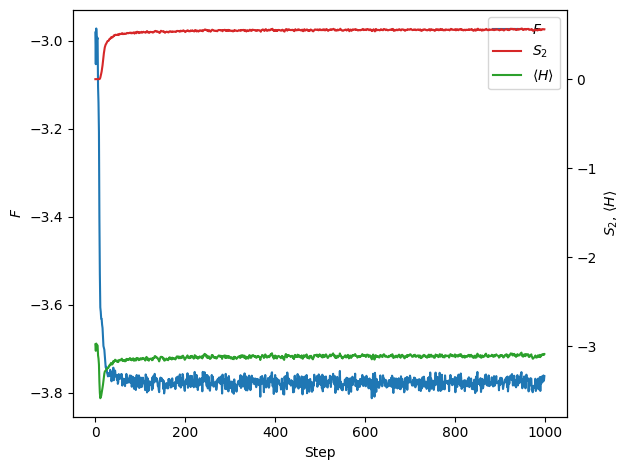

Best solution: S₂=0.553639, E=-3.148466, F=-3.812833


In [49]:
partition = list(range(N))
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=5000)
# vstate = nk.vqs.FullSumState(hi_extended, model)
lr = 0.1
# lr = optax.warmup_cosine_decay_schedule(init_value=0.5, peak_value=0.8, warmup_steps=300, decay_steps=1000, end_value=0.2)
# lr = optax.linear_onecycle_schedule(transition_steps=1000, peak_value=0.4, pct_start=0.5, pct_final=0.9, div_factor=10, final_div_factor=100)
optimizer = optax.sgd(learning_rate=lr,momentum=0.3)
# optimizer = nk.optimizer.SR(diag_shift=1e-3)
# optimizer = optax.adam(learning_rate=lr)
T = 1.2

_,_,_,f_best,E_best,S_best = free_energy_minimize(vstate, optimizer, T, partition, H_extended, 5000,isFullSum=False)

print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

In [ ]:
visualize_free_energy_landscape(vstate, H_extended, partition, vstate.parameters, T)

T=0.000 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.051 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.103 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.154 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.205 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.256 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.308 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.359 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.410 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.462 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.513 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.564 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.615 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.667 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.718 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.769 -- F=-3.605551, E=-3.605551, S₂=0.000000, True
T=0.821 -- F=-3.607840, E=-3.453605, S₂=0.187974, True
T=0.872 -- F=-3.621665, E=-3.334598, S₂=0.329283, True
T=0.923 --

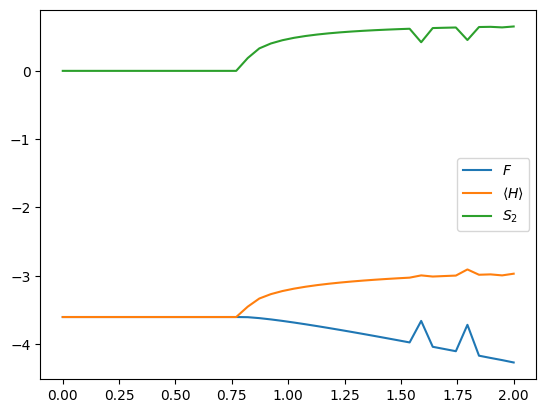

In [33]:
#Minimizar F = <H> - TS₂ en función de T con scipy
T_array = np.linspace(0, 2, 40)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# sampler = nk.sampler.ExactSampler(hilbert=hi_extended)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    # vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_samples=100000,
        method="L-BFGS-B",
        options={"maxiter": 10000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}, {result["result"].success}")

plt.plot(T_array, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Minimizar F = <H> - TS₂ en función de T


sampler = nk.sampler.ExactSampler(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results = []
entropy_results = []  
entropy_netket_results = []  
free_energy_results = []
all_histories = []

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")
    vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
    # lr = optax.warmup_cosine_decay_schedule(init_value=0.5, peak_value=1.5, warmup_steps=300, decay_steps=1000, end_value=0.5)
    lr = 1
    # optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.adam(learning_rate=lr,b1=0.9,b2=0.999))
    # optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.sgd(learning_rate=lr,momentum=0.3))
    optimizer = optax.sgd(lr)
    opt_state = optimizer.init(vstate.parameters)
    n_steps = 1000
    
    F_history, energy_history, entropy_history, best_F, best_energy, best_entropy = free_energy_minimize(
        vstate, optimizer, T, partition, H_extended, n_samples=vstate.n_samples, n_steps=n_steps, verbose=False, normalize_gradients=True, plot=False)
    
    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)
    
    all_histories.append({
        'T': T,
        'energy': energy_history,
        'entropy': entropy_history,
        'free_energy': F_history
    })
    
    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, "
          f"F={best_F:.4f}")

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (SWAP) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | {free_energy_results[i]:13.4f}")

enviar_grafica_telegram()

Temperaturas:   0%|          | 0/30 [00:00<?, ?it/s]


=== Temperatura T = 0.300 ===
  Step 0: E=-2.9892, S₂=0.0000, F=-2.9892, |∇F|=0.1234
  Step 50: E=-3.6055, S₂=0.0000, F=-3.6055, |∇F|=0.0036
  Step 100: E=-3.6056, S₂=-0.0000, F=-3.6056, |∇F|=0.0071
  Step 150: E=-3.6055, S₂=-0.0000, F=-3.6055, |∇F|=0.0100
  Step 200: E=-3.6055, S₂=0.0000, F=-3.6055, |∇F|=0.0152
  Step 250: E=-3.1072, S₂=0.2916, F=-3.1947, |∇F|=2.4616
  Step 300: E=-2.0669, S₂=0.7011, F=-2.2772, |∇F|=0.2847
  Step 350: E=-2.2346, S₂=0.6973, F=-2.4437, |∇F|=0.6138
  Step 400: E=-2.2620, S₂=0.6933, F=-2.4700, |∇F|=0.7135
  Step 450: E=-2.9055, S₂=0.4913, F=-3.0529, |∇F|=1.3816
  Step 500: E=-0.6231, S₂=0.7167, F=-0.8382, |∇F|=6.3664
  Step 550: E=0.2430, S₂=0.7494, F=0.0182, |∇F|=8.2300
  Step 600: E=-2.2397, S₂=0.6861, F=-2.4455, |∇F|=5.1206
  Step 650: E=-3.1138, S₂=0.0848, F=-3.1392, |∇F|=2.0390
  Step 700: E=-3.6051, S₂=-0.0001, F=-3.6050, |∇F|=0.0426
  Step 750: E=-3.6056, S₂=0.0000, F=-3.6056, |∇F|=0.0030
  Step 800: E=-3.6055, S₂=0.0001, F=-3.6055, |∇F|=0.0034
  

Temperaturas:   3%|▎         | 1/30 [00:49<23:47, 49.22s/it]

  Mejor resultado: E=-3.6056, S₂=0.0003, F=-3.6057

=== Temperatura T = 0.359 ===
  Step 0: E=-2.9670, S₂=0.0006, F=-2.9673, |∇F|=0.1094
  Step 50: E=-3.6056, S₂=-0.0001, F=-3.6056, |∇F|=0.0084
  Step 100: E=-3.6056, S₂=0.0000, F=-3.6056, |∇F|=0.0115
  Step 150: E=-3.6038, S₂=0.0000, F=-3.6038, |∇F|=0.1100
  Step 200: E=-3.6055, S₂=0.0000, F=-3.6055, |∇F|=0.0044
  Step 250: E=1.1626, S₂=0.6353, F=0.9347, |∇F|=3.0624
  Step 300: E=-2.2442, S₂=0.7869, F=-2.5264, |∇F|=1.4806
  Step 350: E=-3.5593, S₂=0.0036, F=-3.5606, |∇F|=0.8752
  Step 400: E=-2.2012, S₂=0.6903, F=-2.4488, |∇F|=0.3265
  Step 450: E=-1.2148, S₂=0.7364, F=-1.4789, |∇F|=8.6873
  Step 500: E=-1.1531, S₂=0.7368, F=-1.4173, |∇F|=9.7366
  Step 550: E=-2.3258, S₂=0.7382, F=-2.5905, |∇F|=2.7315
  Step 600: E=-2.0911, S₂=0.6926, F=-2.3395, |∇F|=0.3361
  Step 650: E=-0.4439, S₂=0.7064, F=-0.6972, |∇F|=8.3324
  Step 700: E=-2.4885, S₂=0.6827, F=-2.7334, |∇F|=0.6268
  Step 750: E=-2.5002, S₂=0.7017, F=-2.7518, |∇F|=0.0027
  Step 800

Temperaturas:   7%|▋         | 2/30 [01:36<22:19, 47.85s/it]

...

  Mejor resultado: E=-2.9611, S₂=0.6499, F=-4.1847

=== Temperatura T = 1.941 ===
  Step 0: E=-2.9876, S₂=0.0002, F=-2.9880, |∇F|=0.0629
  Step 50: E=-3.6055, S₂=-0.0000, F=-3.6055, |∇F|=0.0568
  Step 100: E=-3.6054, S₂=-0.0001, F=-3.6051, |∇F|=0.0657
  Step 150: E=-3.6056, S₂=0.0001, F=-3.6057, |∇F|=0.0147
  Step 200: E=-3.6014, S₂=0.0005, F=-3.6025, |∇F|=0.1521
  Step 250: E=-1.0994, S₂=0.7238, F=-2.5046, |∇F|=7.7457
  Step 300: E=-2.0020, S₂=0.7144, F=-3.3889, |∇F|=0.0000
  Step 350: E=-0.2977, S₂=0.6536, F=-1.5666, |∇F|=6.8905
  Step 400: E=-3.0752, S₂=0.4276, F=-3.9054, |∇F|=1.3467
  Step 450: E=-2.0166, S₂=0.6763, F=-3.3295, |∇F|=0.0649
  Step 500: E=-2.8954, S₂=0.2214, F=-3.3252, |∇F|=2.4505
  Step 550: E=-2.7003, S₂=0.5342, F=-3.7373, |∇F|=4.1363
  Step 600: E=-0.4796, S₂=0.4683, F=-1.3888, |∇F|=6.7309
  Step 650: E=-2.4196, S₂=0.4517, F=-3.2965, |∇F|=3.6965
  Step 700: E=-3.6048, S₂=0.0004, F=-3.6055, |∇F|=0.0357
  Step 750: E=-3.6053, S₂=0.0001, F=-3.6056, |∇F|=0.0257
  Step 

Temperaturas:  97%|█████████▋| 29/30 [25:19<00:54, 55.00s/it]

  Mejor resultado: E=-2.8784, S₂=0.6769, F=-4.1926

=== Temperatura T = 2.000 ===
  Step 0: E=-2.9867, S₂=0.0001, F=-2.9868, |∇F|=0.1346
  Step 50: E=-3.6055, S₂=0.0003, F=-3.6061, |∇F|=0.0396
  Step 100: E=-3.6054, S₂=-0.0000, F=-3.6054, |∇F|=0.0449
  Step 150: E=-3.6051, S₂=-0.0000, F=-3.6050, |∇F|=0.0448
  Step 200: E=-3.6047, S₂=0.0014, F=-3.6074, |∇F|=0.0560
  Step 250: E=-2.7740, S₂=0.4982, F=-3.7704, |∇F|=1.4134
  Step 300: E=-2.0561, S₂=0.6938, F=-3.4438, |∇F|=0.1914
  Step 350: E=-2.5125, S₂=0.6153, F=-3.7431, |∇F|=1.9928
  Step 400: E=-1.9837, S₂=0.1354, F=-2.2544, |∇F|=5.4287
  Step 450: E=0.2652, S₂=0.7135, F=-1.1618, |∇F|=5.8011
  Step 500: E=-0.0503, S₂=0.7016, F=-1.4536, |∇F|=8.0204
  Step 550: E=-0.3321, S₂=0.7149, F=-1.7619, |∇F|=8.9372
  Step 600: E=-3.1557, S₂=0.0151, F=-3.1859, |∇F|=2.7086
  Step 650: E=-3.5828, S₂=0.0050, F=-3.5928, |∇F|=0.6316
  Step 700: E=-3.5881, S₂=0.0115, F=-3.6111, |∇F|=0.4559
  Step 750: E=-3.6054, S₂=0.0003, F=-3.6059, |∇F|=0.0300
  Step 8

Temperaturas: 100%|██████████| 30/30 [26:16<00:00, 52.57s/it]

  Mejor resultado: E=-2.9728, S₂=0.6200, F=-4.2128


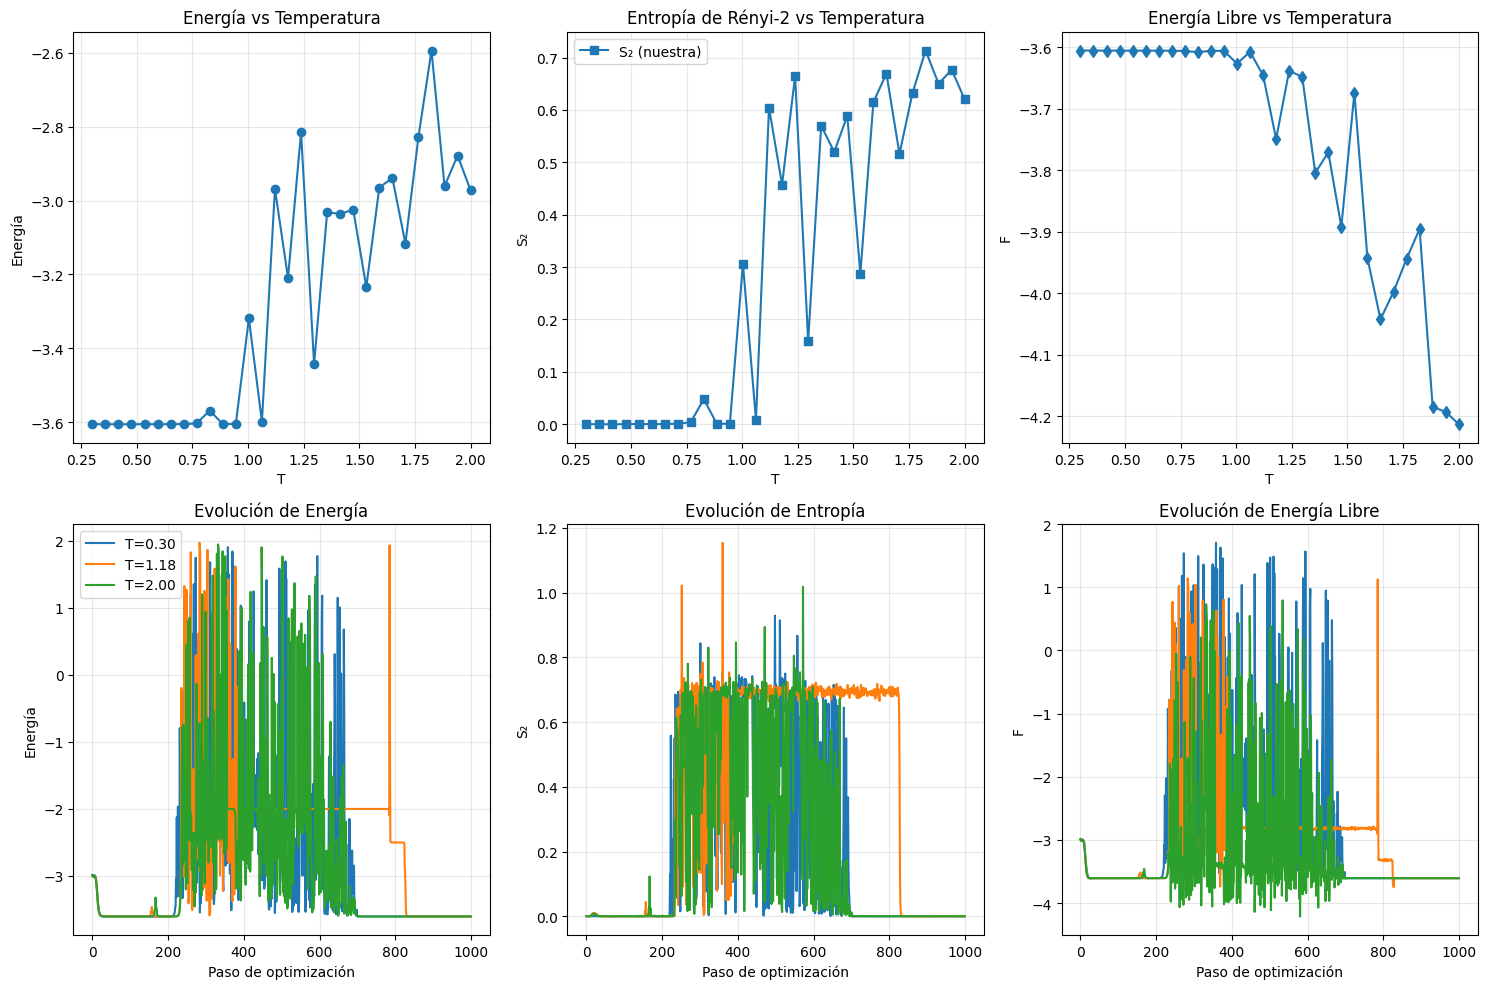


=== RESUMEN DE RESULTADOS ===
Temperatura | Energía | S₂ (SWAP) | Energía Libre
----------------------------------------------------------------------
     0.300 |  -3.6056 |       0.0003 |       -3.6057
     0.359 |  -3.6056 |       0.0000 |       -3.6056
     0.417 |  -3.6058 |      -0.0000 |       -3.6058
     0.476 |  -3.6057 |       0.0001 |       -3.6057
     0.534 |  -3.6056 |       0.0005 |       -3.6059
     0.593 |  -3.6057 |       0.0001 |       -3.6058
     0.652 |  -3.6055 |       0.0005 |       -3.6058
     0.710 |  -3.6052 |       0.0010 |       -3.6059
     0.769 |  -3.6035 |       0.0038 |       -3.6064
     0.828 |  -3.5686 |       0.0480 |       -3.6083
     0.886 |  -3.6052 |       0.0009 |       -3.6060
     0.945 |  -3.6051 |       0.0011 |       -3.6062
     1.003 |  -3.3194 |       0.3064 |       -3.6268
     1.062 |  -3.5986 |       0.0087 |       -3.6078
     1.121 |  -2.9684 |       0.6044 |       -3.6457
     1.179 |  -3.2098 |       0.4575 |       -3.7492


True

In [56]:
# Minimizar F = <H> - T S₂ usando SR +SGD
T_array = np.linspace(0.3, 2, 30)

sampler = nk.sampler.ExactSampler(hi_extended)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []

n_steps = 1000

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate = nk.vqs.MCState(
        sampler,
        model,
        n_samples=50000,
    )

    # --- Learning rate schedule ---
    lr_schedule = optax.warmup_cosine_decay_schedule(init_value=0.0,peak_value=0.4,warmup_steps=250,decay_steps=n_steps,end_value=0.1)
    # lr_schedule = optax.cosine_decay_schedule(init_value=0.4,decay_steps=n_steps,alpha=0.5)

    optimizer = nk.optimizer.Sgd(learning_rate=lr_schedule)

    # --- Stochastic Reconfiguration ---
    sr = nk.optimizer.SR(
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps)
    )

    energy_history = []
    entropy_history = []
    F_history = []

    best_F = np.inf
    best_energy = None
    best_entropy = None

    for step in range(n_steps):
        # ---- Energy ----
        E, E_grad = vstate.expect_and_grad(H_extended)

        # ---- Entropy ----
        S2_val, S2_grad = renyi2_entropy_and_grad_sampled(
            vstate,
            subsystem_sites=partition,
            n_samples=8000,
            key=step,
        )

        # ---- Free energy gradient ----
        F_grad = jax.tree_util.tree_map(
            lambda gE, gS: gE - T * gS,
            E_grad,
            S2_grad,
        )

        # ---- SR step ----
        delta = sr(vstate, F_grad, step)
        lr = lr_schedule(step)

        updates = jax.tree_util.tree_map(lambda x: -lr * x, delta)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)

        # ---- Scalars ----
        F = E.mean.real - T * S2_val

        energy_history.append(E.mean.real)
        entropy_history.append(S2_val)
        F_history.append(F)

        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2_val

        if step % 50 == 0:
            grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(F_grad)[0])
            print(
                f"  Step {step}: "
                f"E={E.mean.real:.4f}, "
                f"S₂={S2_val:.4f}, "
                f"F={F:.4f}, "
                f"|∇F|={grad_norm:.4f}"
            )

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append(
        {
            "T": T,
            "energy": energy_history,
            "entropy": entropy_history,
            "free_energy": F_history,
        }
    )

    print(
        f"  Mejor resultado: "
        f"E={best_energy:.4f}, "
        f"S₂={best_entropy:.4f}, "
        f"F={best_F:.4f}"
    )
# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (SWAP) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | {free_energy_results[i]:13.4f}")

enviar_grafica_telegram()

ValueError: x and y must have same first dimension, but have shapes (20,) and (40,)

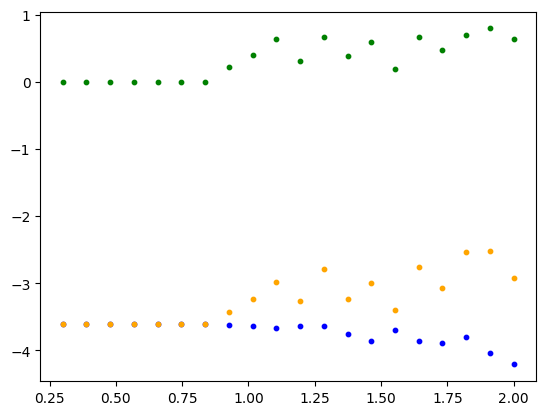

In [55]:
plt.scatter(T_array, free_energy_results, color="Blue", s=10)
plt.scatter(T_array, energy_results, color="Orange", s=10)
plt.scatter(T_array, entropy_results, color="Green", s=10)
plt.plot(T_array, free_energy_results_scipy, label=r"$F$", color="Blue")
plt.plot(T_array, energy_results_scipy, label=r"$\langle H\rangle$", color="Orange")
plt.plot(T_array, entropy_results_scipy, label=r"$S_2$", color="Green")
plt.legend()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
enviar_grafica_telegram()
plt.show()

In [51]:
#Avisar de que ha acabado
import requests
import os
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

def enviar_grafica_telegram():

    bot_token = os.getenv("TELEGRAM_TOKEN")
    chat_id = os.getenv("TELEGRAM_ID")

    archivo = "output.png"

    if not os.path.exists(archivo):
        requests.post(
            f"https://api.telegram.org/bot{bot_token}/sendMessage",
            json={"chat_id": chat_id, "text": f"❌ No existe {archivo}"}
        )
        return False

    with open(archivo, "rb") as f:
        files = {"photo": f}

        caption = (
            "✅ Notebook completado\n"
            f"📅 {datetime.now():%Y-%m-%d %H:%M:%S}\n"
            f"📁 {os.path.getsize(archivo)/1024:.1f} KB"
        )

        response = requests.post(
            f"https://api.telegram.org/bot{bot_token}/sendPhoto",
            data={"chat_id": chat_id, "caption": caption},
            files=files
        )

    if not response.ok:
        print("Error Telegram:", response.text)

    return response.ok

